### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from _03_01_function_to_normalize_sgrna_lfc import *

In [3]:
lfc_data = pd.read_csv("../data/sgrna_lfc_data/yusa_data/KYLogfoldChange.csv", sep =',')
lfc_data = lfc_data.rename(columns={lfc_data.columns[0]: 'spacer'})
lfc_data.shape

# select specific columns
lfc_data = lfc_data.iloc[:, :4]
lfc_data.head(25)

,spacer,22RV1_c908R1_KY-1,22RV1_c908R2_KY-1,22RV1_c908R3_KY-1
0,TGCTGACGGGTGACACCCA,-0.273310,0.110016,-1.192116
1,CGGGGGTGATCCAGGACAC,-1.566878,-1.480434,-0.859840
2,TCAATGGTCACAGTAGCGC,0.158508,0.149881,-0.264145
3,CTGCAGCTACCGGACCGAT,0.262659,0.545221,0.095092
4,GACTTCCAGCTACGGCGCG,-0.771932,-0.498931,0.085523
5,ATCTTATCGGAGATGAAAA,0.857264,0.345390,0.191340
6,TATAAGCTCATCCTCAAAA,1.675061,1.206255,1.769466
7,AATCGGCAGTTGTCCACAC,-0.217815,0.015511,-0.195683
8,ACATGGTATTGCAGTAGAC,-0.427250,-1.137125,-1.230725
9,AATATGGTGGCCCTCCACC,-0.224042,-0.009792,0.353305


In [4]:
# import library data
library_data = pd.read_csv("../data/library_data/yusa_hcrispr_ko_grnas.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
display(library_data.shape)

# import common essential genes
list_common_essential = import_common_essential()

(90709, 3)

In [5]:
lfc = pd.merge(lfc_data, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="gene")
lfc

,,,22RV1_c908R1_KY-1,22RV1_c908R2_KY-1,22RV1_c908R3_KY-1
sgRNA,spacer,gene,,,
sgA1BG_5,TGCTGACGGGTGACACCCA,A1BG,-0.273310,0.110016,-1.192116
sgA1BG_4,CGGGGGTGATCCAGGACAC,A1BG,-1.566878,-1.480434,-0.859840
sgA1BG_2,TCAATGGTCACAGTAGCGC,A1BG,0.158508,0.149881,-0.264145
sgA1BG_3,CTGCAGCTACCGGACCGAT,A1BG,0.262659,0.545221,0.095092
sgA1BG_1,GACTTCCAGCTACGGCGCG,A1BG,-0.771932,-0.498931,0.085523
...,...,...,...,...,...
sgZZZ3_4,GACTACTGAGCCAGCTACA,ZZZ3,-0.260613,-0.146663,-0.478446
sgZZZ3_5,GCTGATTAACATGTTCCAC,ZZZ3,-0.761955,-0.751583,-0.256441
sgZZZ3_3,GAAAACACCAATAACGAAC,ZZZ3,-0.763678,-0.751472,-0.616015


In [6]:
# normalize data by median
lfc_norm = lfc.apply(normalize_column, axis=0)

Scale factor:  0.9864233616475231


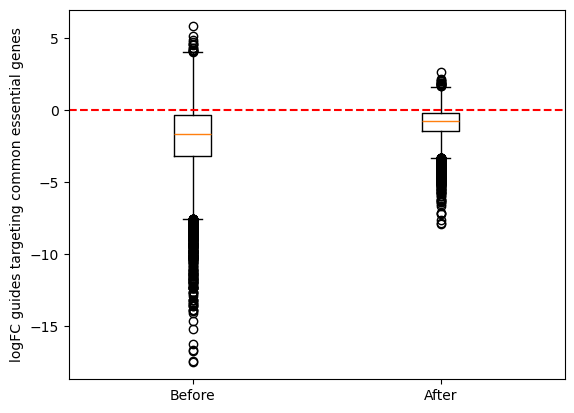

In [7]:
lfc_norm_scaled, list_common_essential = scale_essential(lfc)
sanity_check_scale_essential(lfc_norm, lfc_norm_scaled, list_common_essential)

In [8]:
lfc_norm_scaled_avg = mean_row(lfc_norm_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_5,TGCTGACGGGTGACACCCA,A1BG,-0.458022
1,sgA1BG_4,CGGGGGTGATCCAGGACAC,A1BG,-1.320309
2,sgA1BG_2,TCAATGGTCACAGTAGCGC,A1BG,0.014951
3,sgA1BG_3,CTGCAGCTACCGGACCGAT,A1BG,0.305133
4,sgA1BG_1,GACTTCCAGCTACGGCGCG,A1BG,-0.400552
...,...,...,...,...
89472,sgZZZ3_4,GACTACTGAGCCAGCTACA,ZZZ3,-0.299304
89473,sgZZZ3_5,GCTGATTAACATGTTCCAC,ZZZ3,-0.598113
89474,sgZZZ3_3,GAAAACACCAATAACGAAC,ZZZ3,-0.720166
89475,sgZZZ3_2,GTGGGACTACCTCTGGTAG,ZZZ3,-0.323920


In [9]:
lfc_norm_scaled_avg.to_csv("../data/sgrna_lfc_data/output_normalized/yusa_normalized_lfc_3_rep.csv", index=False)